In [1]:
import sys
import os
import numpy as np
import json
from pathlib import Path

# ── paths ─────────────────────────────────────────────────────────────────────
REPO = Path("C:/Users/ameli/Desktop/TezBaselines")
DTS  = REPO / "Diffusion-TS"

sys.path.insert(0, str(REPO))
sys.path.insert(0, str(DTS))

# ── swap these two blocks to switch between models ────────────────────────────

# DiffusionTS own results
REAL_NPY = REPO / "Diffusion-TS/OUTPUT/stock/samples/stock_norm_truth_24_train.npy"
FAKE_NPY = REPO / "Diffusion-TS/OUTPUT/stock/ddpm_fake_stock.npy"
OUT_JSON = REPO / "DecompDiff/output/datas/dtss_results.json"

# DecompDiff results
# REAL_NPY = REPO / "DecompDiff/output/datas/decompdiff_real_32.npy"
# FAKE_NPY = REPO / "DecompDiff/output/datas/decompdiff_fake_32.npy"
# OUT_JSON = REPO / "DecompDiff/output/datas/dts_results.json"

real = np.load(REAL_NPY).astype(np.float32)
fake = np.load(FAKE_NPY).astype(np.float32)

# align N — metrics require equal number of samples
n = min(len(real), len(fake))
real = real[:n]
fake = fake[:n]

print(f"real : {real.shape}  [{real.min():.4f}, {real.max():.4f}]")
print(f"fake : {fake.shape}  [{fake.min():.4f}, {fake.max():.4f}]")

results = {}

real : (3662, 24, 6)  [0.0000, 1.0000]
fake : (3662, 24, 6)  [0.0130, 0.9958]


Feature          DD KL    DD Wass    DTS KL   DTS Wass
-------------------------------------------------------
Open            0.2423     0.0537    0.2387     0.0445
High            0.2599     0.0559    0.2807     0.0448
Low             0.2460     0.0560    0.2187     0.0450
Close           0.2465     0.0546    0.2184     0.0448
AdjClose        0.2517     0.0553    0.2163     0.0444
Volume          0.1784     0.0174    0.1504     0.0184


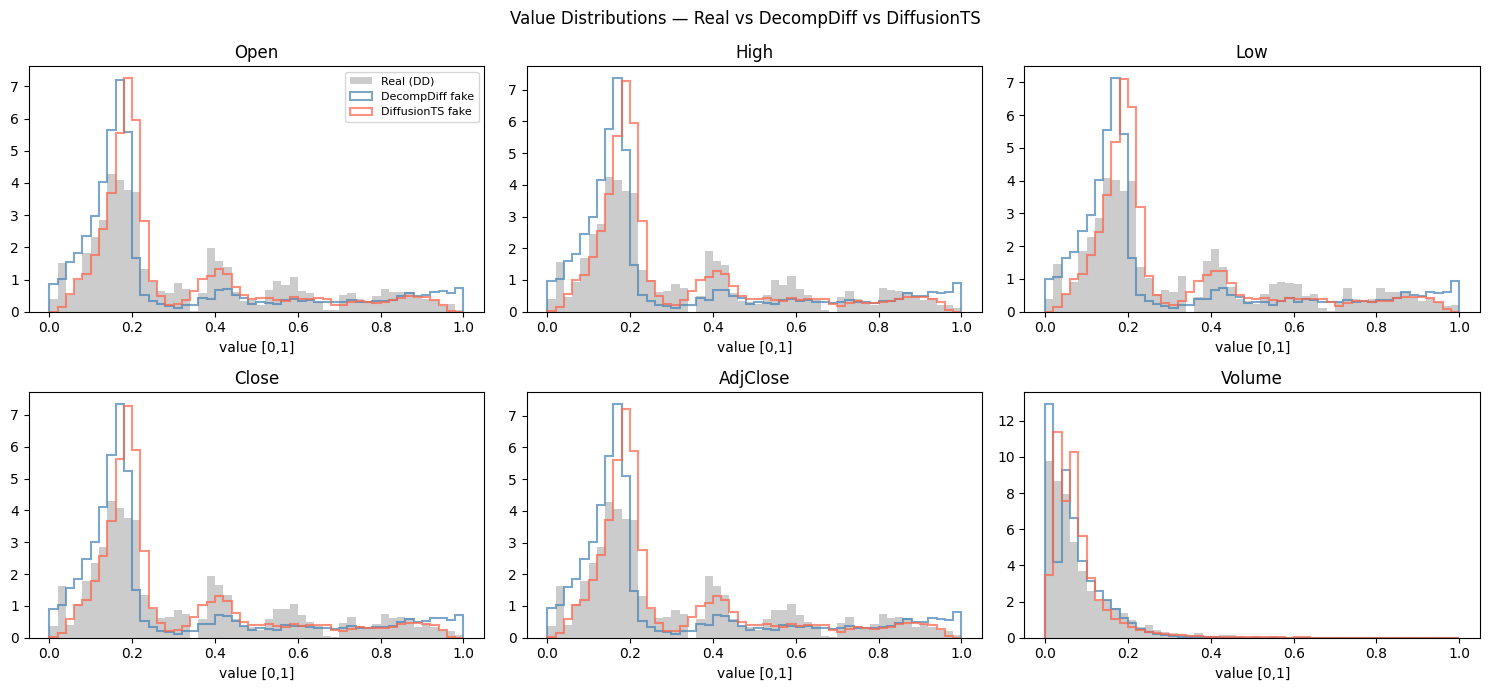

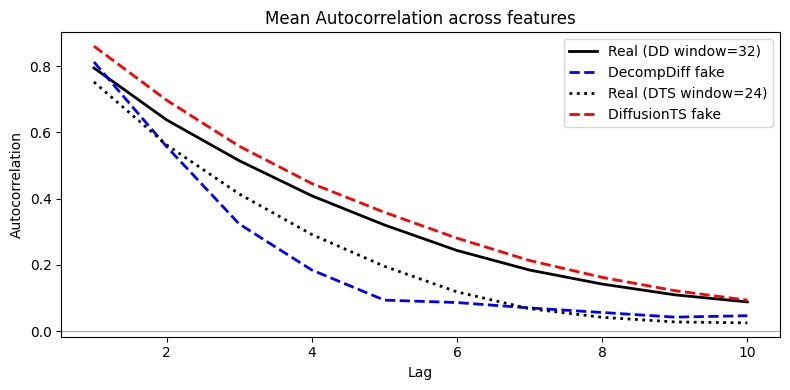

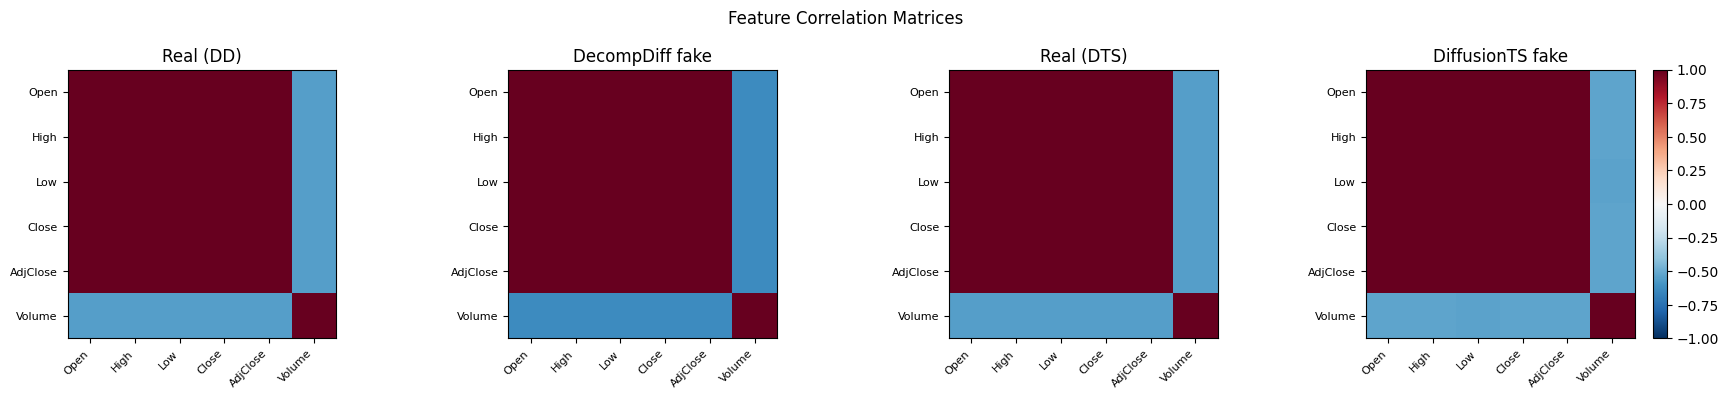

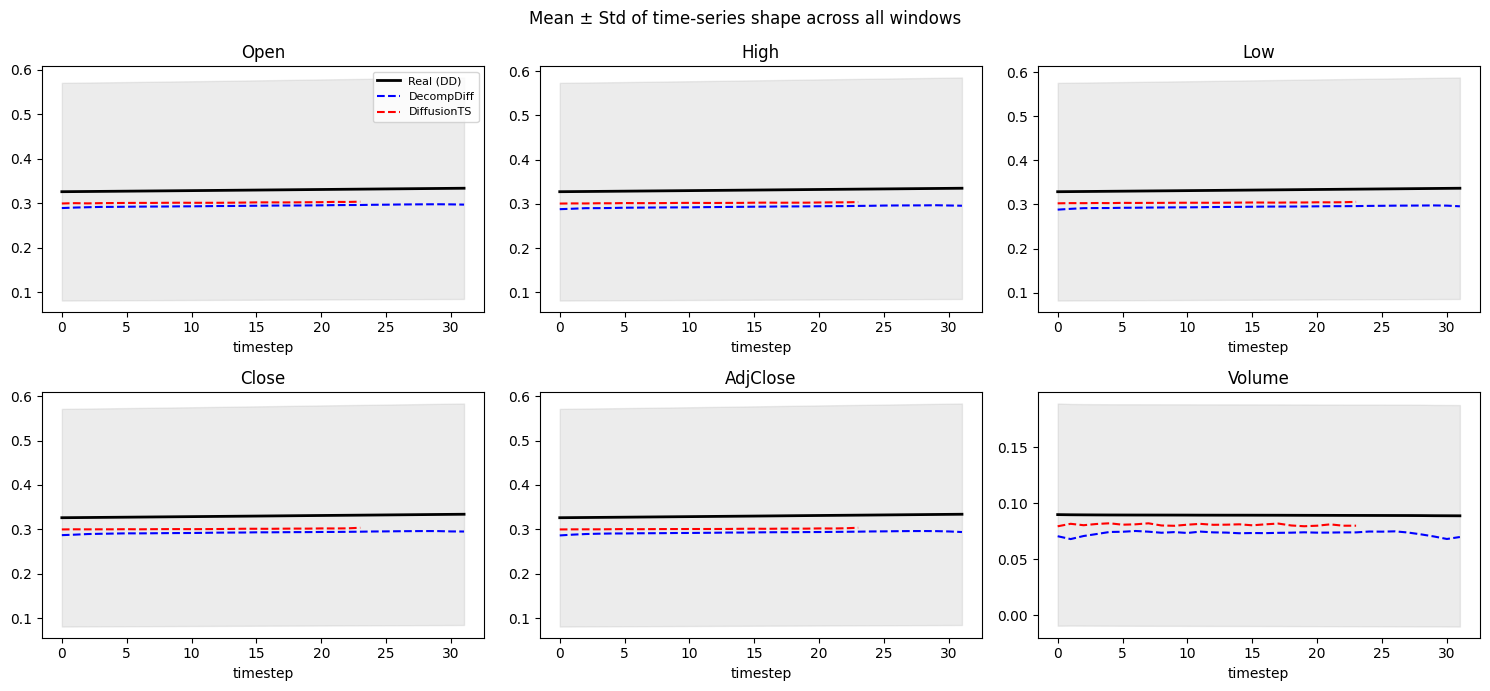

In [6]:
import matplotlib
if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = lambda key: matplotlib.rcParams[key]

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy, wasserstein_distance
from pathlib import Path

REPO = Path("C:/Users/ameli/Desktop/TezBaselines")

dd_real  = np.load(REPO / "DecompDiff/output/datas/decompdiff_real_32.npy")
dd_fake  = np.load(REPO / "DecompDiff/output/datas/decompdiff_fake_32.npy")
dts_real = np.load(REPO / "Diffusion-TS/OUTPUT/stocks/samples/stock_norm_truth_24_train.npy")
dts_fake = np.load(REPO / "Diffusion-TS/OUTPUT/stocks/ddpm_fake_stocks.npy")

n1 = min(len(dd_real),  len(dd_fake));  dd_real,  dd_fake  = dd_real[:n1],  dd_fake[:n1]
n2 = min(len(dts_real), len(dts_fake)); dts_real, dts_fake = dts_real[:n2], dts_fake[:n2]

FEAT = ["Open", "High", "Low", "Close", "AdjClose", "Volume"]

def kl(a, b, bins=50):
    lo, hi = min(a.min(), b.min()), max(a.max(), b.max())
    pa = np.histogram(a, bins=bins, range=(lo,hi))[0].astype(float)+1e-10
    pb = np.histogram(b, bins=bins, range=(lo,hi))[0].astype(float)+1e-10
    pa/=pa.sum(); pb/=pb.sum()
    return float(entropy(pa, pb))

def wass(a, b):
    return float(wasserstein_distance(a.flatten(), b.flatten()))

def mean_autocorr(data, max_lag=10):
    acf = np.zeros(max_lag)
    for lag in range(1, max_lag+1):
        x, y = data[:, :-lag, :], data[:, lag:, :]
        xm, ym = x - x.mean(axis=1, keepdims=True), y - y.mean(axis=1, keepdims=True)
        acf[lag-1] = ((xm*ym).mean(axis=1) / (x.std(axis=1)*y.std(axis=1)+1e-8)).mean()
    return acf

def corr_matrix(data):
    return np.corrcoef(data.reshape(-1, data.shape[-1]).T)

# ── 1. KL & Wasserstein table ─────────────────────────────────────────────────
print(f"{'Feature':<12}  {'DD KL':>8}  {'DD Wass':>9}  {'DTS KL':>8}  {'DTS Wass':>9}")
print("-" * 55)
for i, f in enumerate(FEAT):
    print(f"{f:<12}  {kl(dd_real[:,:,i], dd_fake[:,:,i]):>8.4f}  {wass(dd_real[:,:,i], dd_fake[:,:,i]):>9.4f}"
          f"  {kl(dts_real[:,:,i], dts_fake[:,:,i]):>8.4f}  {wass(dts_real[:,:,i], dts_fake[:,:,i]):>9.4f}")

# ── 2. Value distributions ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for i, (ax, f) in enumerate(zip(axes.flatten(), FEAT)):
    bins = np.linspace(0, 1, 51)
    ax.hist(dd_real[:,:,i].flatten(),  bins=bins, alpha=0.4, color="gray",      label="Real (DD)",        density=True)
    ax.hist(dd_fake[:,:,i].flatten(),  bins=bins, alpha=0.7, color="steelblue", label="DecompDiff fake",  density=True, histtype="step", linewidth=1.5)
    ax.hist(dts_fake[:,:,i].flatten(), bins=bins, alpha=0.7, color="tomato",    label="DiffusionTS fake", density=True, histtype="step", linewidth=1.5)
    ax.set_title(f); ax.set_xlabel("value [0,1]")
    if i == 0: ax.legend(fontsize=8)
plt.suptitle("Value Distributions — Real vs DecompDiff vs DiffusionTS", fontsize=12)
plt.tight_layout(); plt.show()

# ── 3. Autocorrelation ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(1, 11)
ax.plot(x, mean_autocorr(dd_real),  "k-",  lw=2, label="Real (DD window=32)")
ax.plot(x, mean_autocorr(dd_fake),  "b--", lw=2, label="DecompDiff fake")
ax.plot(x, mean_autocorr(dts_real), "k:",  lw=2, label="Real (DTS window=24)")
ax.plot(x, mean_autocorr(dts_fake), "r--", lw=2, label="DiffusionTS fake")
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("Lag"); ax.set_ylabel("Autocorrelation")
ax.set_title("Mean Autocorrelation across features")
ax.legend(); plt.tight_layout(); plt.show()

# ── 4. Feature correlation heatmaps ───────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, data, title in zip(axes, [dd_real, dd_fake, dts_real, dts_fake],
                                  ["Real (DD)", "DecompDiff fake", "Real (DTS)", "DiffusionTS fake"]):
    im = ax.imshow(corr_matrix(data), vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(6)); ax.set_yticks(range(6))
    ax.set_xticklabels(FEAT, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(FEAT, fontsize=8); ax.set_title(title)
plt.colorbar(im, ax=axes[-1])
plt.suptitle("Feature Correlation Matrices", fontsize=12)
plt.tight_layout(); plt.show()

# ── 5. Mean ± std time-series shape ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for i, (ax, f) in enumerate(zip(axes.flatten(), FEAT)):
    t1 = np.arange(dd_real.shape[1])
    t2 = np.arange(min(32, dts_fake.shape[1]))
    ax.plot(t1, dd_real.mean(0)[:,i], "k-", lw=2, label="Real (DD)")
    ax.fill_between(t1,
                    dd_real.mean(0)[:,i] - dd_real.std(0)[:,i],
                    dd_real.mean(0)[:,i] + dd_real.std(0)[:,i],
                    alpha=0.15, color="gray")
    ax.plot(t1, dd_fake.mean(0)[:,i],       "b--", lw=1.5, label="DecompDiff")
    ax.plot(t2, dts_fake.mean(0)[:len(t2),i], "r--", lw=1.5, label="DiffusionTS")
    ax.set_title(f); ax.set_xlabel("timestep")
    if i == 0: ax.legend(fontsize=8)
plt.suptitle("Mean ± Std of time-series shape across all windows", fontsize=12)
plt.tight_layout(); plt.show()


In [3]:
def clamp_report(arr, name):
    N, L, C = arr.shape
    # per window: does it touch the hard boundary?
    w_has_zero  = (arr == 0.0).any(axis=(1, 2))
    w_has_one   = (arr == 1.0).any(axis=(1, 2))
    w_either    = w_has_zero | w_has_one
    w_natural   = ~w_either

    # per individual value
    n_zero = int((arr == 0.0).sum())
    n_one  = int((arr == 1.0).sum())
    total  = arr.size

    print(f"\n{'='*55}")
    print(f"  {name}   (N={N}, L={L}, C={C})")
    print(f"{'='*55}")
    print(f"  Windows touching 0.0 exactly : {w_has_zero.sum():>5}  ({100*w_has_zero.mean():.1f}%)")
    print(f"  Windows touching 1.0 exactly : {w_has_one.sum():>5}  ({100*w_has_one.mean():.1f}%)")
    print(f"  Windows touching either bound : {w_either.sum():>5}  ({100*w_either.mean():.1f}%)")
    print(f"  Windows fully in (0, 1) open : {w_natural.sum():>5}  ({100*w_natural.mean():.1f}%)  ← no clamping fired")
    print(f"  ---")
    print(f"  Individual values at 0.0     : {n_zero:>8} / {total}  ({100*n_zero/total:.4f}%)")
    print(f"  Individual values at 1.0     : {n_one:>8} / {total}  ({100*n_one/total:.4f}%)")
dd_real  = np.load(REPO / "DecompDiff/output/datas/decompdiff_real_32.npy")
dd_fake  = np.load(REPO / "DecompDiff/output/datas/decompdiff_fake_32.npy")
dts_real = np.load(REPO / "Diffusion-TS/OUTPUT/stocks/samples/stock_norm_truth_24_train.npy")
dts_fake = np.load(REPO / "Diffusion-TS/OUTPUT/stocks/ddpm_fake_stocks.npy")
clamp_report(dd_real,  "DecompDiff  — REAL")
clamp_report(dd_fake,  "DecompDiff  — FAKE")
clamp_report(dts_real, "DiffusionTS — REAL")
clamp_report(dts_fake, "DiffusionTS — FAKE")



  DecompDiff  — REAL   (N=3654, L=32, C=6)
  Windows touching 0.0 exactly :    44  (1.2%)
  Windows touching 1.0 exactly :    65  (1.8%)
  Windows touching either bound :   109  (3.0%)
  Windows fully in (0, 1) open :  3545  (97.0%)  ← no clamping fired
  ---
  Individual values at 0.0     :       80 / 701568  (0.0114%)
  Individual values at 1.0     :      160 / 701568  (0.0228%)

  DecompDiff  — FAKE   (N=3654, L=32, C=6)
  Windows touching 0.0 exactly :    35  (1.0%)
  Windows touching 1.0 exactly :    69  (1.9%)
  Windows touching either bound :   104  (2.8%)
  Windows fully in (0, 1) open :  3550  (97.2%)  ← no clamping fired
  ---
  Individual values at 0.0     :     2127 / 701568  (0.3032%)
  Individual values at 1.0     :     3688 / 701568  (0.5257%)

  DiffusionTS — REAL   (N=3662, L=24, C=6)
  Windows touching 0.0 exactly :    36  (1.0%)
  Windows touching 1.0 exactly :    25  (0.7%)
  Windows touching either bound :    61  (1.7%)
  Windows fully in (0, 1) open :  3601  (98.

In [4]:
print(dd_fake[0 ])

[[0.15276313 0.14961833 0.15071937 0.14950359 0.14866859 0.07110944]
 [0.15249386 0.14998114 0.15125221 0.14994192 0.14927459 0.06120601]
 [0.15076625 0.14883548 0.15011004 0.14916968 0.14817351 0.06334242]
 [0.15034327 0.14821321 0.14980686 0.14885134 0.14810741 0.06909597]
 [0.15021706 0.1482768  0.14949343 0.14925846 0.14864805 0.07743838]
 [0.15175977 0.15033409 0.15072384 0.1509834  0.15002805 0.08613157]
 [0.15254903 0.15093428 0.1513252  0.15111151 0.15099144 0.08568284]
 [0.15469658 0.15226421 0.15411389 0.15316147 0.15238804 0.0622547 ]
 [0.15616676 0.15391606 0.15588921 0.15491465 0.15397042 0.04493877]
 [0.15636793 0.1547082  0.15583739 0.15550366 0.15523446 0.06190333]
 [0.15623847 0.15480882 0.15553826 0.15554214 0.15540674 0.07389659]
 [0.15718725 0.15559015 0.15655437 0.15642095 0.1559318  0.06682512]
 [0.15807796 0.1561122  0.15749219 0.15742055 0.15642625 0.06236079]
 [0.15737328 0.15603095 0.15640661 0.15681589 0.15645286 0.07890937]
 [0.1579529  0.1562486  0.15704373

In [13]:
# ── discriminative score ──────────────────────────────────────────────────────
# Must disable eager execution BEFORE importing the TF1-compat metric modules.
import tensorflow as tf
tf.compat.v1.disable_eager_execution()

from Utils.discriminative_metric import discriminative_score_metrics

disc, fake_acc, real_acc = discriminative_score_metrics(real, fake)
results["discriminative_score"] = float(disc)
results["fake_acc"]             = float(fake_acc)
results["real_acc"]             = float(real_acc)
print(f"Discriminative : {disc:.4f}  (fake_acc={fake_acc:.4f}  real_acc={real_acc:.4f})")

C:\Users\ameli\Desktop\TezBaselines\Diffusion-TS\Utils\discriminative_metric.py:100: UserWarning: `tf.nn.rnn_cell.GRUCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.GRUCell`, and will be replaced by that in Tensorflow 2.0.
  d_cell = tf1.nn.rnn_cell.GRUCell(num_units=hidden_dim, activation=tf.nn.tanh, name = 'd_cell')
C:\Users\ameli\Desktop\TezBaselines\Diffusion-TS\Utils\discriminative_metric.py:103: UserWarning: `tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.
  y_hat_logit = tf1.layers.dense(d_last_states, 1, activation=None)
training: 100%|██████████| 2000/2000 [00:12<00:00, 160.73it/s]

Discriminative : 0.2278  (fake_acc=0.7250  real_acc=0.7305)


In [ ]:
# ── predictive score ──────────────────────────────────────────────────────────
from Utils.predictive_metric import predictive_score_metrics

pred = predictive_score_metrics(real, fake)
results["predictive_score"] = float(pred)
print(f"Predictive MAE : {pred:.4f}")

In [ ]:
# ── Context-FID (TS2Vec) ──────────────────────────────────────────────────────
from Utils.context_fid import Context_FID

cfid = Context_FID(real, fake)
results["context_fid"] = float(cfid)
print(f"Context-FID    : {cfid:.4f}")

In [ ]:
# ── cross-correlation ─────────────────────────────────────────────────────────
import torch
from Utils.cross_correlation import CrossCorrelLoss

real_t = torch.from_numpy(real).float()
fake_t = torch.from_numpy(fake).float()
cc = CrossCorrelLoss(real_t, name="cc")(fake_t).item()
results["cross_correlation"] = float(cc)
print(f"Cross-corr     : {cc:.4f}")

In [ ]:
# ── summary ───────────────────────────────────────────────────────────────────
print("=" * 45)
for k, v in results.items():
    print(f"  {k:<25}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

with open(OUT_JSON, "w") as f:
    json.dump(results, f, indent=2)
print(f"\nSaved -> {OUT_JSON}")